<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/A0_001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

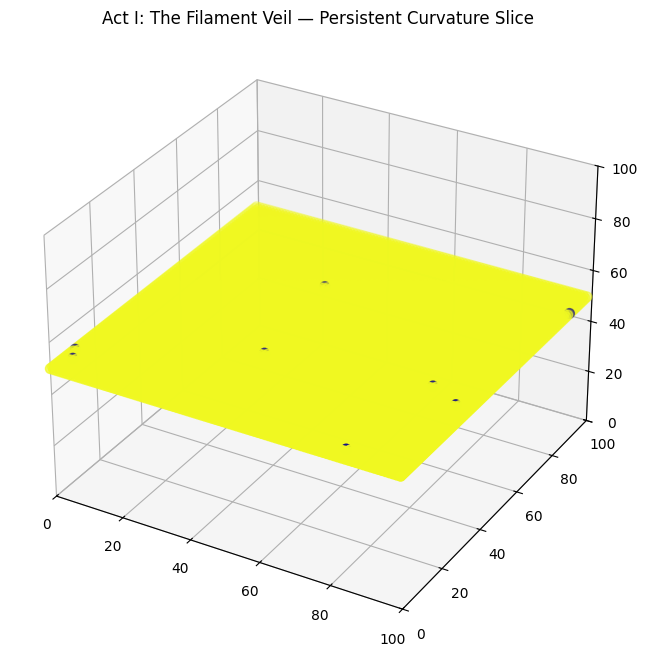

In [1]:
# GENESIS001 — Act Ø + Act I: The Whisper of Emergence & The Filament Veil
# Pure emergence of curvature and filamentary structure from Laplacian dynamics

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
L = 100  # lattice size
steps = 200  # time steps
alpha = 0.4      # local interaction
beta = 0.005     # damping
gamma = 0.0001   # global entropy feedback
threshold = 0.002  # curvature sensitivity

# Initialize lattice
s = np.random.uniform(-1.0, 1.0, (L, L, L))

# Seed asymmetry
s[40:60, 40:60, 40:60] += 0.5  # expansion pocket
s[70:80, 70:80, 70:80] -= 0.5  # contraction pocket

# Gaussian-weighted Laplacian kernel
def laplacian_3d(s):
    kernel = np.array([[[0.05, 0.1, 0.05],
                        [0.1,  0.4, 0.1],
                        [0.05, 0.1, 0.05]],
                       [[0.1,  0.4, 0.1],
                        [0.4, -6.0, 0.4],
                        [0.1,  0.4, 0.1]],
                       [[0.05, 0.1, 0.05],
                        [0.1,  0.4, 0.1],
                        [0.05, 0.1, 0.05]]])
    from scipy.ndimage import convolve
    return convolve(s, kernel, mode='wrap')

# Track persistent curvature
density = np.zeros_like(s)

# Evolve lattice
for _ in range(steps):
    lap = laplacian_3d(s)
    global_entropy = np.mean(s)
    s += alpha * lap - beta * s - gamma * global_entropy
    density += (np.abs(lap) > threshold).astype(float)

# Visualize slice through center
z_slice = L // 2
slice_density = density[:, :, z_slice]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
x, y = np.meshgrid(np.arange(L), np.arange(L))
x, y = x.flatten(), y.flatten()
z = np.full_like(x, z_slice)
c = slice_density.flatten()
s = 10 + 40 * (c / np.max(c))  # scale size
ax.scatter(x, y, z, c=c, cmap='plasma', s=s)
ax.set_title("Act I: The Filament Veil — Persistent Curvature Slice")
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
plt.show()
